In [1]:
# Import Libraries
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
centers = [
    (-5, -5),
    (5, 5),
    (0, 7),
    (6, -4)
]

cluster_std = [1, 1, 1, 1]
X, y = make_blobs(
    n_samples = 300,
    centers=centers,
    cluster_std=cluster_std,
    n_features=2,
    random_state=42
)

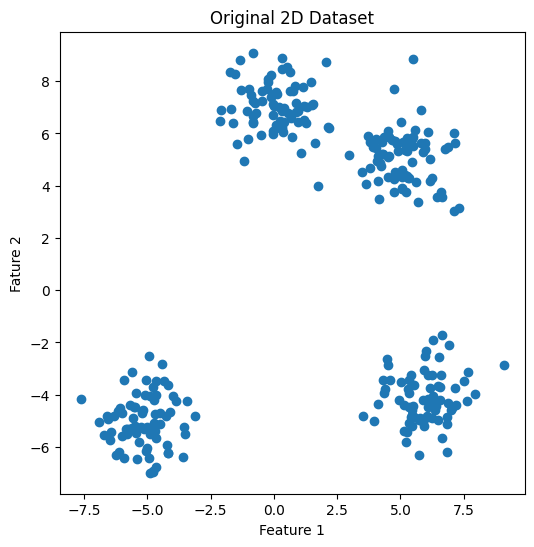

In [3]:
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1])
plt.title("Original 2D Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Fature 2")
plt.show()

In [4]:
km = KMeans(n_clusters=4)
km.fit(X)

KMeans(n_clusters=4)

In [5]:
labels = km.predict(X)

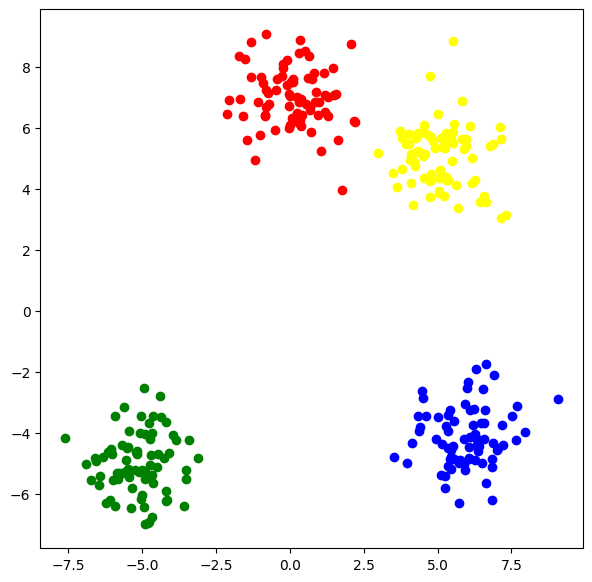

In [6]:
colors = ["red", "green", "blue", "yellow"]
plt.figure(figsize=(7, 7))

for i in range(4):
  plt.scatter(
      X[labels == i, 0],
      X[labels == i, 1],
      color= colors[i],
      label=f"Cluster {i + 1}"
  )

In [7]:
wcss = []

for k in range(1, 11):
  km = KMeans(n_clusters=k)
  km.fit(X)
  wcss.append(km.inertia_)

In [8]:
wcss

[15144.493257215827,
 7432.8752670211825,
 1649.8603414902464,
 561.2234585563442,
 507.5665499405539,
 469.1157615367727,
 419.1173007287307,
 362.9101757569659,
 352.9058717790943,
 310.60394555578705]

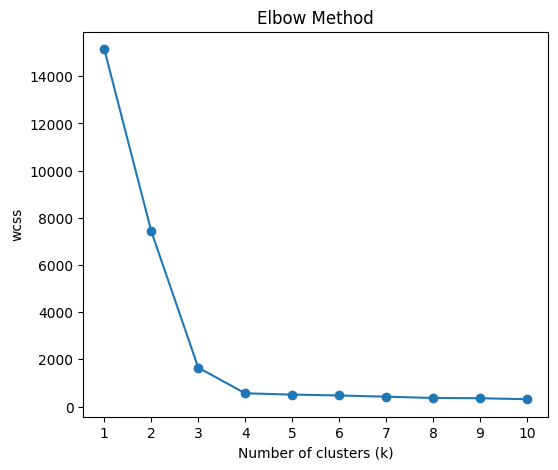

In [9]:
# Elbow Curve

plt.figure(figsize=(6, 5))
plt.plot(range(1,11), wcss, marker="o")
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters (k)")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

## Generate 3D Dataset

In [10]:
centroids = [
    (-5, -5, 5),
    (5, 5, -5),
    (3.5, -2.5, 4),
    (-2.5, 2.5, -4)
]

cluster_std = [1, 1, 1, 1]

X, y = make_blobs(
    n_samples=200,
    centers=centroids,
    cluster_std=cluster_std,
    n_features=3,
    random_state=1
)

In [11]:

import plotly.express as px
import pandas as pd

In [12]:
fig = px.scatter_3d(
    x = X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    title = ("Original 3D dataset")
)
fig.show()

In [13]:
wcss = []

for k in range(1, 20):
  km = KMeans(n_clusters=k)
  km.fit(X)
  wcss.append(km.inertia_)

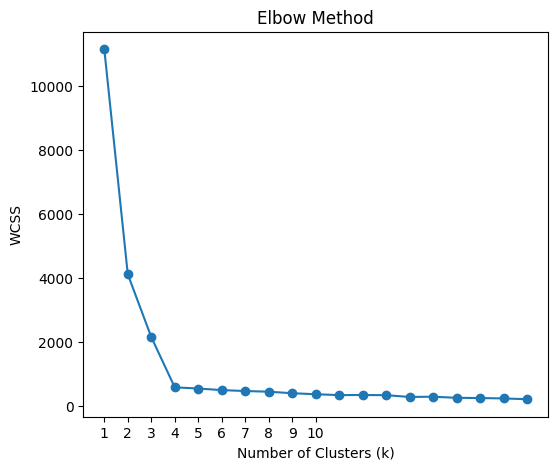

In [14]:
plt.figure(figsize=(6, 5))
plt.plot(range(1, 20), wcss, marker="o")
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [15]:
km = KMeans(n_clusters=4)
km.fit(X)

KMeans(n_clusters=4)

In [16]:
labels = km.predict(X)

In [17]:
result = pd.DataFrame({
    "X" : X[:, 0],
    "Y" : X[:, 1],
    "Z" : X[:, 2],
    "Cluster" : labels
})

In [19]:
fig = px.scatter_3d(
    result,
    x="X",
    y="Y",
    z="Z",
    color="Cluster",
    title="K-Means Clustering (3D)"
)

fig.show()